11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


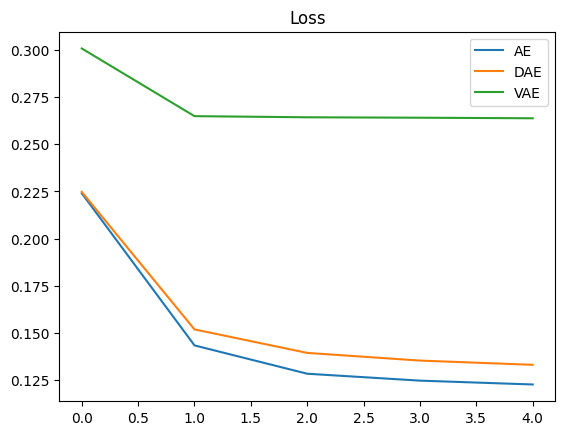

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


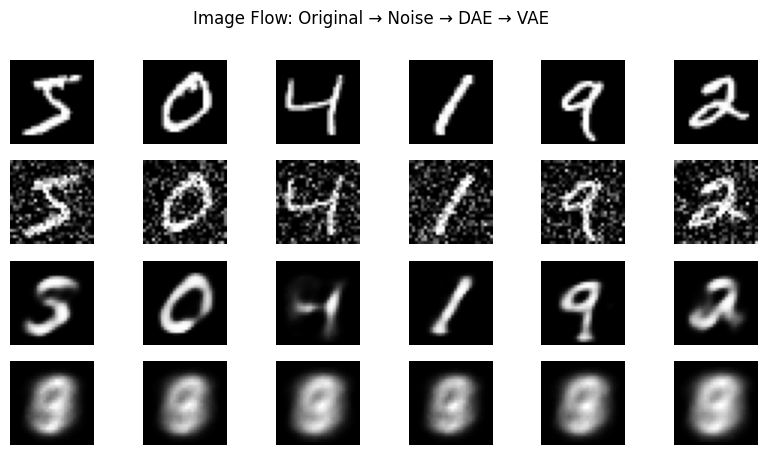

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

# ---------------- Data ----------------
(x_train, _), _ = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = x_train.reshape(-1, 784)

latent_dim, epochs, batch_size = 16, 5, 128

# ---------------- AE ----------------
inp = layers.Input(shape=(784,))
z = layers.Dense(128, activation='relu')(inp)
z = layers.Dense(latent_dim)(z)
out = layers.Dense(784, activation='sigmoid')(z)

ae = Model(inp, out)
ae.compile(optimizer='adam', loss='binary_crossentropy')

# ---------------- DAE ----------------
noise = 0.3
x_noisy = np.clip(x_train + noise * np.random.randn(*x_train.shape), 0., 1.)

dae = tf.keras.models.clone_model(ae)
dae.compile(optimizer='adam', loss='binary_crossentropy')

# ---------------- VAE ----------------
class VAE(Model):
    def __init__(self):
        super().__init__()
        self.fc1 = layers.Dense(128, activation='relu')
        self.mu = layers.Dense(latent_dim)
        self.logvar = layers.Dense(latent_dim)
        self.fc2 = layers.Dense(128, activation='relu')
        self.out = layers.Dense(784, activation='sigmoid')

    def call(self, x):
        h = self.fc1(x)
        mu, logvar = self.mu(h), self.logvar(h)
        eps = tf.random.normal(shape=tf.shape(mu))
        z = mu + tf.exp(0.5 * logvar) * eps
        recon = self.out(self.fc2(z))

        kl = -0.5 * tf.reduce_mean(1 + logvar - tf.square(mu) - tf.exp(logvar))
        self.add_loss(kl)

        return recon

vae = VAE()
vae.compile(optimizer='adam', loss='binary_crossentropy')

# ---------------- Train ----------------
h1 = ae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=0)
h2 = dae.fit(x_noisy, x_train, epochs=epochs, batch_size=batch_size, verbose=0)
h3 = vae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=0)

# ---------------- Loss Plot ----------------
plt.plot(h1.history['loss'], label='AE')
plt.plot(h2.history['loss'], label='DAE')
plt.plot(h3.history['loss'], label='VAE')
plt.legend()
plt.title("Loss")
plt.show()

# ---------------- Show Images ----------------
n = 6
orig = x_train[:n]
noisy = x_noisy[:n]

ae_out = ae.predict(orig)
dae_out = dae.predict(noisy)
vae_out = vae.predict(orig)

titles = ["Original", "Noisy Input", "DAE Output", "VAE Output"]

plt.figure(figsize=(10, 5))

for row, data in enumerate([orig, noisy, dae_out, vae_out]):
    for i in range(n):
        plt.subplot(4, n, row * n + i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel(titles[row])

plt.suptitle("Image Flow: Original → Noise → DAE → VAE")
plt.show()